# Homework 4: The Bootstrap

BEE 4850/5850, Fall 2025

**Name**: Madeline Allen

**ID**:

> **Due Date**
>
> Friday, 3/28/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice simulation-based
uncertainty quantification, focusing on the bootstrap.

-   Problem 1 asks you to use the non-parametric bootstrap to estimate
    uncertainty in a Poisson regression model.
-   Problem 2 asks you to use the bootstrap (through resampling
    residuals) to estimate uncertainty in a semi-empirical sea-level
    rise model.
-   Problem 3 (only required for students in BEE 5850) asks you to use a
    moving block bootstrap to estimate the sampling distribution of the
    median of extreme water level data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [119]:
import random  # random number generation and seed-setting
import pandas as pd  # tabular data structure
import csv  # reads/writes .csv files (though pandas is usually used for this)
import numpy as np  # numerical computing
import scipy.stats as stats  # interface to work with probability distributions
import matplotlib.pyplot as plt  # plotting library
import seaborn as sns  # additional statistical plotting tools
import statistics  # statistical quantities like mean, median, etc.
from scipy.optimize import minimize  # optimization tools
from scipy.stats import norm
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson
random.seed(44)


## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Revisit the salamander model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html), using
percent groundcover as a predictor in the Poisson regression. Use the
non-parametric bootstrap to estimate bias and confidence intervals for
the model parameters.

**In this problem**:

-   Load the data from `data/salamanders.csv`.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Use 1,000 non-parametric bootstrap samples to obtain estimates of
    bias and the 90% confidence interval for the intercept and
    coefficient in the Poisson regression.

In [27]:
sal = pd.read_csv("data/salamanders.csv", delimiter=";") 
print(sal.head(5))

   SITE  SALAMAN  PCTCOVER  FORESTAGE
0     1       13        85        316
1     2       11        86         88
2     3       11        90        548
3     4        9        88         64
4     5        8        89         43


In [28]:
# Standardize predictors
sal['PCTCOVER_scale'] = (sal['PCTCOVER'] - sal['PCTCOVER'].mean())/sal['PCTCOVER'].std()

The structure of my poisson model is:

$y_i \sim Poisson(\lambda_i)$

$f(\lambda_i) = beta_0 + beta_1 * PCTCOVER$

$\lambda_i = f^{-1} (beta_0 + beta_1 * PCTCOVER)$

And for this Poisson model, I think it makes sense to use the log link function (converting all real numbers that come out of the $beta_0 + beta_1 * PCTCOVER$ into only postive rate constant values).

So my model would be:

$y_i \sim Poisson(\lambda_i)$ where $\lambda_i = e\^{}(beta_0 + beta_1 * PCTCOVER)$

Note that in the above, I've kept it labeled as "PCTCOVER" but we're actually using a standardized version of that. 

In [124]:
# Fit Poisson 
model = smf.glm(formula='SALAMAN ~ PCTCOVER_scale', data=sal, 
                family=sm.families.Poisson()).fit()
# print(model.summary())

# Extract estimated parameters
β0_hat = model.params['Intercept']
β1_hat = model.params['PCTCOVER_scale']

# Compute predicted lambda values and prediction intervals
sal['est_lambda_hat'] = model.predict(sal)

# 90% prediction interval (5th and 95th percentiles of the predicted Poisson dist)
sal['lower_bound'] = poisson.ppf(0.05, sal['est_lambda_hat'])
sal['upper_bound'] = poisson.ppf(0.95, sal['est_lambda_hat'])


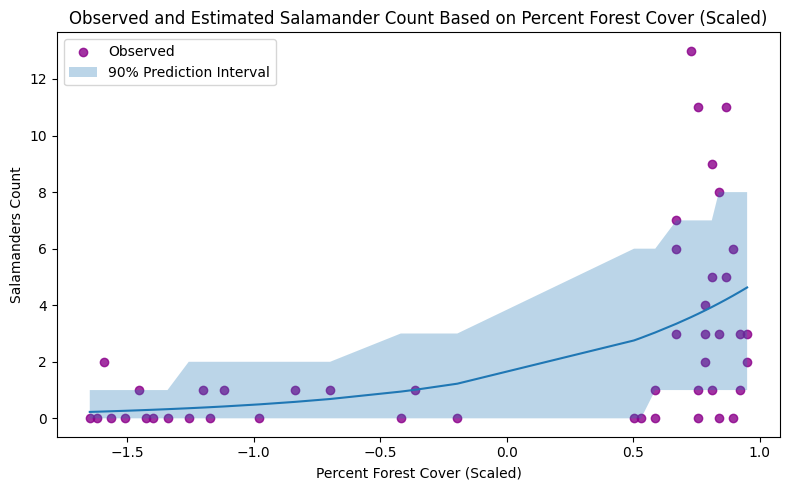

In [120]:
# Plot:
plt.figure(figsize=(8,5)) 
plt.scatter(sal['PCTCOVER_scale'], sal['SALAMAN'], label = 'Observed', color = 'darkmagenta', alpha = 0.8)
# plot 90% prediction intervals using the stored sal['lower_bound'] and sal['upper_bound']
sorted_df = sal.sort_values('PCTCOVER_scale')
plt.plot(sorted_df['PCTCOVER_scale'], sorted_df['est_lambda_hat'])
plt.fill_between(sorted_df['PCTCOVER_scale'], sorted_df['lower_bound'], sorted_df['upper_bound'], alpha= 0.3, label = '90% Prediction Interval')

# Add labels
plt.xlabel('Percent Forest Cover (Scaled)')
plt.ylabel('Salamanders Count')
plt.title('Observed and Estimated Salamander Count Based on Percent Forest Cover (Scaled)')
plt.legend()
plt.tight_layout()
plt.show()

Now for the bootstrap:

In [ ]:
# Use 1,000 non-parametric bootstrap samples to obtain estimates of bias and the 90% confidence interval 
# for the intercept and coefficient in the Poisson regression.
n_boot = 1000

sal_boot = sal.sample(n=len(sal),replace=True)
sal_boot

#np random choice len of data... extract...  


,SITE,SALAMAN,PCTCOVER,FORESTAGE,PCTCOVER_scale,est_lambda_hat,lower_bound,upper_bound
4,5,8,89,43,0.839127,4.065289,1.0,8.0
32,33,0,5,2,-1.508764,0.267159,0.0,1.0
24,25,1,46,30,-0.362769,1.008917,0.0,3.0
24,25,1,46,30,-0.362769,1.008917,0.0,3.0
4,5,8,89,43,0.839127,4.065289,1.0,8.0
35,36,0,11,6,-1.341058,0.324505,0.0,1.0
45,46,0,89,60,0.839127,4.065289,1.0,8.0
0,1,13,85,316,0.727323,3.571004,1.0,7.0
17,18,2,87,30,0.783225,3.810140,1.0,7.0
23,24,1,34,49,-0.698183,0.683837,0.0,2.0


In [128]:
sal

,SITE,SALAMAN,PCTCOVER,FORESTAGE,PCTCOVER_scale,est_lambda_hat,lower_bound,upper_bound
0,1,13,85,316,0.727323,3.571004,1.0,7.0
1,2,11,86,88,0.755274,3.688635,1.0,7.0
2,3,11,90,548,0.867079,4.199201,1.0,8.0
3,4,9,88,64,0.811176,3.935647,1.0,7.0
4,5,8,89,43,0.839127,4.065289,1.0,8.0
5,6,7,83,368,0.671421,3.346878,1.0,7.0
6,7,6,83,200,0.671421,3.346878,1.0,7.0
7,8,6,91,71,0.895030,4.337524,1.0,8.0
8,9,5,88,42,0.811176,3.935647,1.0,7.0
9,10,5,90,551,0.867079,4.199201,1.0,8.0


### Problem 2

Revisit the sea-level rise model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html):

$$\begin{aligned}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{aligned}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

We would like to quantify uncertainty in the model parameters using the
bootstrap.

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data and
    include an initial sea-level parameter $S_0$. This will be similar
    to the model from Homework 2. Fit this model to the data with AR(1)
    residuals.
-   Use your fitted model and the AR(1) residual process to generate
    1,000 parametric bootstrap samples. Refit the model to each. Plot
    histograms of the bootstrap samples for each parameter. What is the
    90% confidence interval for the sensitivity of sea level to global
    mean temperature?

NOTE: similar to question 1, the beginning of my question largely uses code directly from my HW2 submission (just fyi :) ). As described in HW2 (in the suggested modification to the problem, given the time dependence of the residuals), the way I formulated this new model (adding the AR1 component)is: turning the discrepancy term frin HW2 into an AR(1) probability model. I.e., previously, the discrepancy term was normally distributed with mean zero and standard deviation sigma: $\delta_t \sim N(0, \sigma^2)$, I instead make the discrepancy term equal to $\delta_t = \delta_{t-1} + \omega_t$, where $\omega_t \sim N(0, \sigma^2)$. By changing this model formulation and again use MLE to obtain estimates of the parameters (now, with the addition of $\rho$).

In [139]:
#  Load data
temp = pd.read_csv("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv") 
sea = pd.read_csv("data/CSIRO_Recons_gmsl_yr_2015.csv") 

# Round down the time on sea_lev_anom for simplicity, since 1880.5 is the mean sea level in 1880, as noted in ed discussion post
sea['Time'] = sea['Time'].astype(int)

# normalize both datasets to the 1980-1999 mean
temp_mean = temp[(temp['Time']>=1980) & (temp['Time']<=1999)]['Anomaly (deg C)'].mean()
print('Mean temp anomaly from 1980-1999:', temp_mean)
sea_mean = sea[(sea['Time']>=1980) & (sea['Time']<=1999)]['GMSL (mm)'].mean()
print('Mean sea level anomaly from 1980-1999:', sea_mean)

# subtract mean from data:
temp['temp_anom_normalized'] = temp['Anomaly (deg C)'] - temp_mean
sea['GMSL_anom_normalized'] = sea['GMSL (mm)'] - sea_mean
# print(temp.head(10))
# print(sea.head(10))

# # Figure out what years both datasets contain:
# print('temp min year: ', temp['Time'].min())
# print('temp max year: ', temp['Time'].max())
# print('sea min year: ', sea['Time'].min())
# print('sea max year: ', sea['Time'].max())

# we want 1880-2013; filter datasets:
temp_filt = temp[(temp['Time']>=1880)&(temp['Time']<=2013)].reset_index(drop=True)
sea_filt = sea[(sea['Time']>=1880)&(sea['Time']<=2013)].reset_index(drop=True)


Mean temp anomaly from 1980-1999: 0.24016621270000002
Mean sea level anomaly from 1980-1999: 0.375


In [140]:
# Function to simulate global mean sea levels under a set of model parameters (discretized eqn):
def sea_level_model(a, b, tau, S0, global_temp = temp_filt['temp_anom_normalized']):    
    dt = 1 # 1 year 
    T = global_temp
    S = np.zeros(len(T))
    S[0] = S0    
    for i in range(len(T) - 1):
        S[i+1] = S[i] + ((a * T[i] + b - S[i])/tau)*dt
    return S


In [141]:
def neg_log_likelihood_ar1(params, sea_level_data=sea_filt['GMSL_anom_normalized'], global_temp=temp_filt['temp_anom_normalized']):
    a, b, tau, S0, rho, sigma = params

    # Simulate sea level using the model
    sea_level_sim = sea_level_model(a, b, tau, S0, global_temp=global_temp)

    # Compute residuals
    residuals =  sea_level_data - sea_level_sim

    # AR(1) whitened log-likelihood
    # T = len(residuals)
    # ll = norm.logpdf(residuals[0], loc=0, scale=np.sqrt(sigma**2 / (1 - rho**2)))
    # for t in range(1, T):
    #     ll += norm.logpdf(residuals[t], loc=rho * residuals[t-1], scale=sigma)
    T = len(residuals)
    ll = 0  # Initialize log-likelihood counter
    
    for i in range(T):
        if i == 0:
            ll += norm.logpdf(residuals[i], loc=0, scale=np.sqrt(sigma**2 / (1 - rho**2)))
        else:
            ll += norm.logpdf(residuals[i], loc=rho * residuals[i-1], scale=sigma)

    return -ll  # negative log-likelihood for minimization

# define lower and upper bounds, and initial parameter estimations
lower = [-2000.0, -2000.0, 0.1, -2000.0, -0.99999999, 0.0000001]
upper = [2000.0, 2000.0, 20000.0, 2000.0, 0.999999999, 10.0]
p0 = [1.0, 1.0, 1.0, 1.0, 0.5, 1.0]

result = minimize(neg_log_likelihood_ar1, p0, bounds=list(zip(lower, upper)), method="SLSQP")
θ_iid = result.x
a_hat, b_hat, tau_hat, S0_hat, rho_hat, sigma_hat = result.x

print('The paramaeter estiatmes for a, b, tau, S0, rho, sigma are: ', θ_iid)


The paramaeter estiatmes for a, b, tau, S0, rho, sigma are:  [ 5.58480181e+02  4.16379063e+02  1.78580097e+02 -1.58091155e+02
  5.10681067e-01  4.93211253e+00]


/Users/mca76/Documents/Courses/EnvDataAnalysis/HW/bee5850_python_env/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


# Christine code to test:

In [142]:
# # load the data
# # global mean temp data
# np.random.seed(44)
# temp_data = pd.read_csv("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv",
#                         sep=",", header=0) #./
# # sea level data
# sea_lvl_data = pd.read_csv("data/CSIRO_Recons_gmsl_yr_2015.csv",
#                            sep=",", header=0) #./

# # normalize the data by subtracting off the mean from 1980-1999
# # from HW2
# temp_data["Anomaly_deg_C_normalized"] = temp_data["Anomaly (deg C)"] - \
#     np.mean(temp_data["Anomaly (deg C)"][130:150]) # 1980-1999 indices
# sea_lvl_data["GMSL_mm_normalized"] = sea_lvl_data["GMSL (mm)"] - \
#     np.mean(sea_lvl_data["GMSL (mm)"][100:120]) # 1980-1999 indices

# # subset the temp data to years we have sea level data (1880-2013)
# # from HW2
# temp_data = temp_data[(temp_data["Time"] >= 1880) & (temp_data["Time"] <= 2013)]
# temp_data = temp_data.reset_index(drop=True) # need to reset the index after filtering the rows

# # from HW2
# # function to simulate global mean sea levels under set of model
# # params after discretizing eqns
# # create model for sea level based on temp
# def sea_level_model(global_temp, p=(1,1,1,1)): # params = a, b, tau, S0
#     # define our unknown param values based on input to function
#     a, b, tau, S0 = p
#     dt = 1 # 1 year
#     T = global_temp
#     S = np.zeros(len(T))
#     # initial sea level parameter, S0
#     S[0] = S0
#     for i in range(len(T) - 1):
#         S[i+1] = S[i] + ((a * T[i] + b - S[i])/tau)*dt
#     return S
# def sea_level_model_wrap(params):
#     return sea_level_model(global_temp=temp_data['Anomaly_deg_C_normalized'],
#                            p=params)

# # fit model under assumption of AR(1) residuals by MLE
# # note: don't need to include observation uncertainty here (from office hours)
# # likelihood for AR(1) process
# # adapted from Time Series Lecture class notes (see references)
# # whitened: remove inter-temporal correlation
# def ar1_loglik_whitened(theta, dat):
#     # unpack parameters
#     rho, sigma = theta
#     T = len(dat)
#     ll = 0  # initialize log-likelihood
#     for i in range(T):
#         if i == 0:
#             ll += norm.logpdf(dat[i], loc=0, scale=np.sqrt(sigma**2 / (1 - rho**2)))
#         else:
#             ll += norm.logpdf(dat[i], loc=rho * dat[i-1], scale=sigma)
#     return ll
# # calculate residuals and pass to AR(1) likelihood function
# # not sure if correct
# def ar1_model_loglik(params, sea_level_obs, model_func):
#     # unpack parameters: a, b, tau, S0, rho, sigma
#     a, b, tau, S0, rho, sigma = params
#     # simulated sea level from model
#     sea_level_sim = model_func((a, b, tau, S0))
#     # compute residuals between observed and simulated sea levels
#     # residual defined as differnece between predicted and observed value
#     # this is epsilon_t
#     residuals = sea_level_obs - sea_level_sim
#     # compute AR(1) log-likelihood using whitened approach (above)
#     # of this residual series
#     ll = ar1_loglik_whitened((rho, sigma), residuals)
#     return ll
# # negative log-likelihood wrapper
# def neg_log_likelihood_ar1(params):
#     return -ar1_model_loglik(
#         params,
#         sea_level_obs=sea_lvl_data["GMSL_mm_normalized"],
#         model_func=sea_level_model_wrap
#     )
# # initial guesses: a, b, tau, S0, rho, sigma
# p0 = [1.0, 1.0, 1.0, 1.0, 0.5, 1.0]
# # set the bounds really wide, to avoid estimating parameter
# # exactly as upper or lower bound
# lower = [-2000, -2000, 0.1, -2000, -0.99, 0]
# upper = [2000, 2000, 2000, 2000, 0.99, 10.0]
# result = minimize(neg_log_likelihood_ar1, p0,
#                   bounds=list(zip(lower, upper)), method="SLSQP")
# θ_ar1 = result.x

# # print the parameter estimates from above
# print("Estimate of 'a': ", θ_ar1[0].round(2), "mm/deg C")
# print("Estimate of 'b': ", θ_ar1[1].round(2), "mm")
# print("Estimate of tau: ", θ_ar1[2].round(2), "years")
# print("Estimate of S0: ", θ_ar1[3].round(2), "mm")
# print("Estimate of rho: ", θ_ar1[4].round(2), "") # autoregressive coefficient (unitless)
# print("Estimate of sigma: ", θ_ar1[5].round(2), "mm") # standard deviation of residual

In [86]:
# # Gaussian iid; calculate the log likelihood (and make it negative so you can easily minimize it in order to find the max likelihood estimates)
# def neg_log_likelihood(params, sea_level_data = sea_filt['GMSL_anom_normalized']):# , m=sea_level_model_wrap):
#     # note - sigma here is standard deviation of the discrepancy term
#     a, b, tau, S0, sigma = params 
#     sea_level_sim = sea_level_model(a, b, tau, S0, global_temp = temp_filt['temp_anom_normalized'])
#     # Assuming gaussian iid; and the error term is a combination of the model error (represented by sigma) 
#     # and the observational error (standard deviation in the sea level measurements)
#     # Note that here, the observational error is different for each observation, as discussed in the comment above
#     ll = np.sum(norm.logpdf(sea_level_data, loc=sea_level_sim, scale=np.sqrt(sigma**2)))
#     # replace line of code above with one that instead uses AR1 for residuals, instead of gaussian iid...
#     # where errors (predicted sea level minus observed) epsilon_t = rho epsilon_tprevious


#     return -ll # return negative log likelihood

## Maddy come back - need to redo above using AR(1) resid model
then bootstrap

Use your fitted model and the AR(1) residual process to generate
    1,000 parametric bootstrap samples. Refit the model to each. Plot
    histograms of the bootstrap samples for each parameter. What is the
    90% confidence interval for the sensitivity of sea level to global
    mean temperature

In [ ]:
# Use fitted model w/ AR(1) resid - generate 1,000 parametric bootstrap samples
simulated_baseline = sea_level_model(a = a_hat, b = b_hat, tau = tau_hat, S0 = S0_hat, global_temp = temp_filt['temp_anom_normalized'])
# 1,000 bootstrap samples from AR(1)
# refit model to each, store new estiamtes of sensitivity of sea level to global mean temp (a parameter)

T = len(simulated_baseline) #length of timeseries

n_sim = 1000

# initialize bootstrap params dataframe to store a, b, tau, S0, rho, sigma (number of rows: n_sim)
bootstrap_params = []

# Simulate synthetic AR(1) series
for sim in range(n_sim):
    error_sim = np.zeros(T)
    for t in range(T):
        if t == 0:
            error_sim[t] = np.random.normal(0, np.sqrt(sigma_hat**2 / (1 - rho_hat**2)))
        else:
            error_sim[t] = np.random.normal(rho_hat * error_sim[t-1], sigma_hat)
    # combine AR(1) error prediction with baseline:
    bootstrap_sim = error_sim + simulated_baseline
    
    #refit model to bootstrap_sim
    


    #store parameters:
    #bootstrap_params.append({"a": a_boot, "b": b_boot, "tau": tau_boot, "S0": S0_boot, "rho": rho_boot, "sigma": sigma_boot})


# Convert to DataFrame
bootstrap_params_df = pd.DataFrame(bootstrap_params)

# plot histograms of bootstrap samples for each parameter; report 90% confidence interval for the sensitivity of sea level to global mean temperature


### Problem 3

Let’s revisit the 2015 Sewell’s Point tide gauge data, which consists of
hourly observations and predicted sea-level based on NOAA’s harmonic
model.

**NOTE: Used ChatGPT (openai, 2025) to convert following Juila code blocks to Python.**

In [37]:
# function load_data(fname)
#     date_format = "yyyy-mm-dd HH:MM"
#     # this uses the DataFramesMeta package -- it's pretty cool
#     return @chain fname begin
#         CSV.File(; dateformat=date_format)
#         DataFrame
#         rename(
#             "Time (GMT)" => "time", "Predicted (m)" => "harmonic", "Verified (m)" => "gauge"
#         )
#         @transform :datetime = (Date.(:Date, "yyyy/mm/dd") + Time.(:time))
#         select(:datetime, :gauge, :harmonic)
#         @transform :weather = :gauge - :harmonic
#         @transform :month = (month.(:datetime))
#     end
# end

# dat = load_data("data/norfolk-hourly-surge-2015.csv")

# plot(dat.datetime, dat.gauge; ylabel="Gauge Measurement (m)", label="Observed", legend=:topleft, xlabel="Date/Time", color=:blue)
# plot!(dat.datetime, dat.harmonic, label="Prediction", color=:orange)

/var/folders/hs/sjsb0x2s0gg5xm3rz3s8n9t00000gn/T/ipykernel_33855/556959089.py:3: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(fname, parse_dates=[["Date", "Time (GMT)"]])


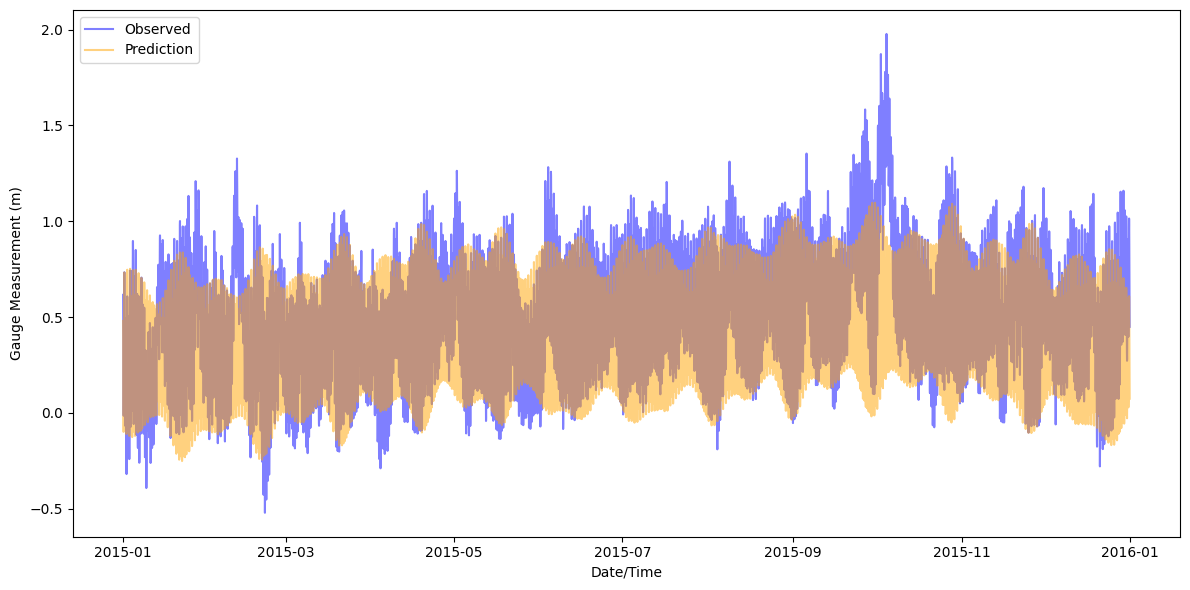

In [67]:
def load_data(fname):
    # Load CSV with parsed datetime
    df = pd.read_csv(fname, parse_dates=[["Date", "Time (GMT)"]])
    
    # Rename columns
    df.rename(columns={
        "Date_Time (GMT)": "datetime",
        "Predicted (m)": "harmonic",
        "Verified (m)": "gauge"
    }, inplace=True)

    # Compute additional columns
    df["weather"] = df["gauge"] - df["harmonic"]
    df["month"] = df["datetime"].dt.month

    return df[["datetime", "gauge", "harmonic", "weather", "month"]]

# Load the data
dat = load_data("data/norfolk-hourly-surge-2015.csv")

tide_median_observed = np.median(dat["gauge"])

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(dat["datetime"], dat["gauge"], label="Observed", color="blue", alpha = 0.5)
plt.plot(dat["datetime"], dat["harmonic"], label="Prediction", color="orange", alpha = 0.5)
plt.xlabel("Date/Time")
plt.ylabel("Gauge Measurement (m)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


We detrend the data to isolate the weather-induced variability by
subtracting the predictions from the observations; the results
(following the Julia code) are in `dat[:, :weather]`.

In [39]:
# plot(dat.datetime, dat.weather; ylabel="Gauge Weather Variability (m)", label="Detrended Data", linewidth=1, legend=:topleft, xlabel="Date/Time")

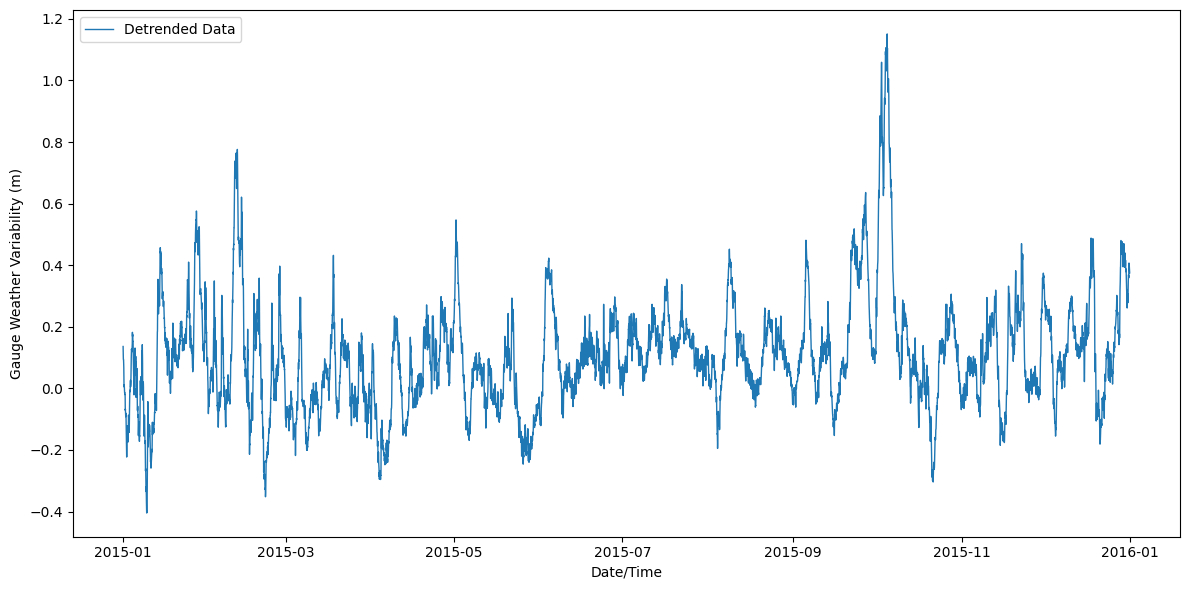

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(dat["datetime"], dat["weather"], label="Detrended Data", linewidth=1)
plt.xlabel("Date/Time")
plt.ylabel("Gauge Weather Variability (m)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()


We would like to understand the uncertainty in an estimate of the median
sea level.

**In this problem**:

-   Construct 1,000 bootstrap replicates by adding a moving block
    bootstrap replicate from the weather-induced variability series
    (with block length 20) to the harmonic prediction. Use these
    replicates to compute a 90% confidence interval. What is the bias of
    the estimator?
-   Repeat the analysis with block length 50. How does this affect the
    confidence intervals and estimate of bias?
-   Why do you think using different block lengths produced the results
    that they did?

**NOTE - use of ChatGPT (OpenAI, 2025) in this quesiton:** I used chatgpt to convert some of the code from the block bootstrap lecture slides from Julia to Python; all subsequent updates to that code were done by me, not ChatGPT.

In [50]:
dat

,datetime,gauge,harmonic,weather,month
0,2015-01-01 00:00:00,0.616,0.480,0.136,1
1,2015-01-01 01:00:00,0.432,0.325,0.107,1
2,2015-01-01 02:00:00,0.242,0.145,0.097,1
3,2015-01-01 03:00:00,0.084,-0.009,0.093,1
4,2015-01-01 04:00:00,-0.006,-0.099,0.093,1
...,...,...,...,...,...
8755,2015-12-31 19:00:00,0.978,0.576,0.402,12
8756,2015-12-31 20:00:00,0.876,0.480,0.396,12
8757,2015-12-31 21:00:00,0.731,0.342,0.389,12
8758,2015-12-31 22:00:00,0.576,0.193,0.383,12


The bootstrap (block length = 20) estimated median tide level is 0.51 meters;
the 90% confidence interval in median tide level is 0.5 m to 0.53 m.
The bias in this estimator (observed median minus bootstrap estiamte) is -0.0049 m.


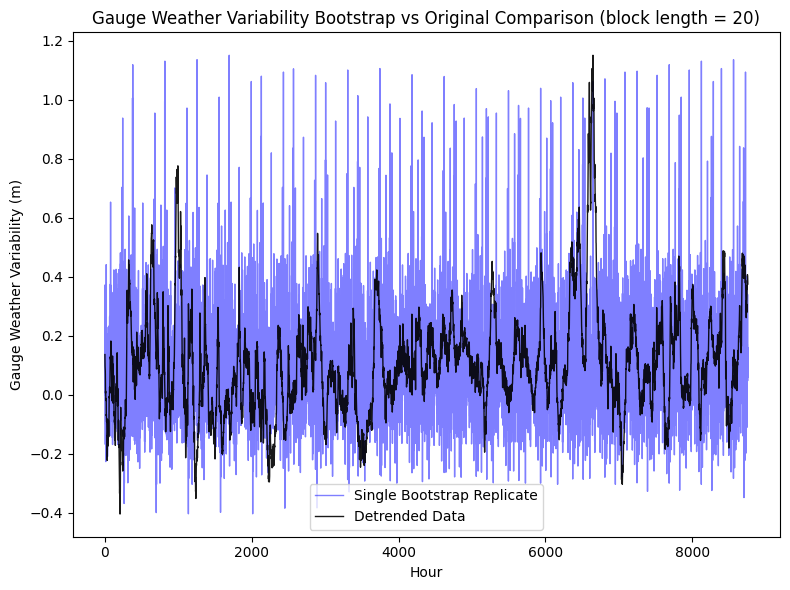

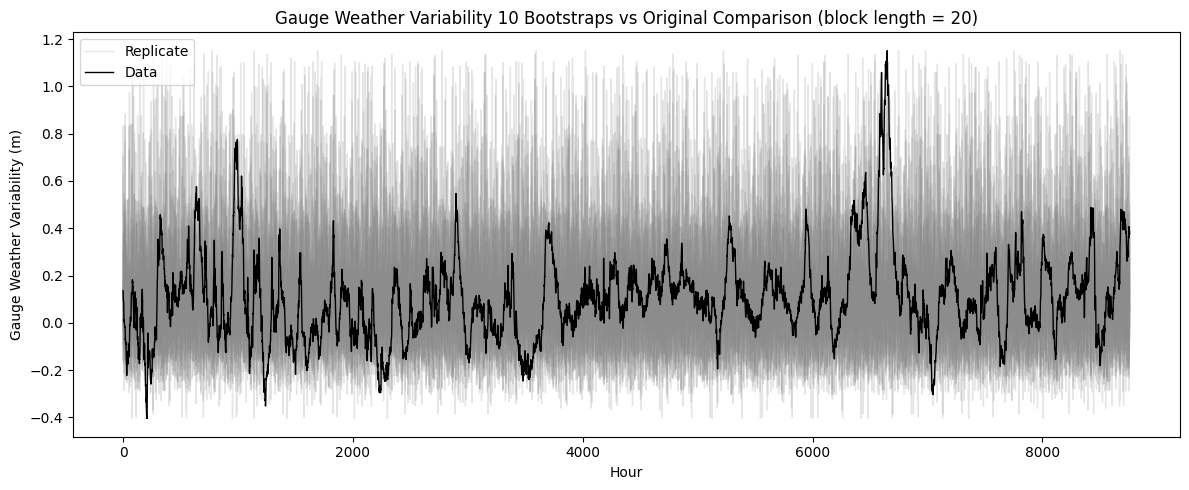

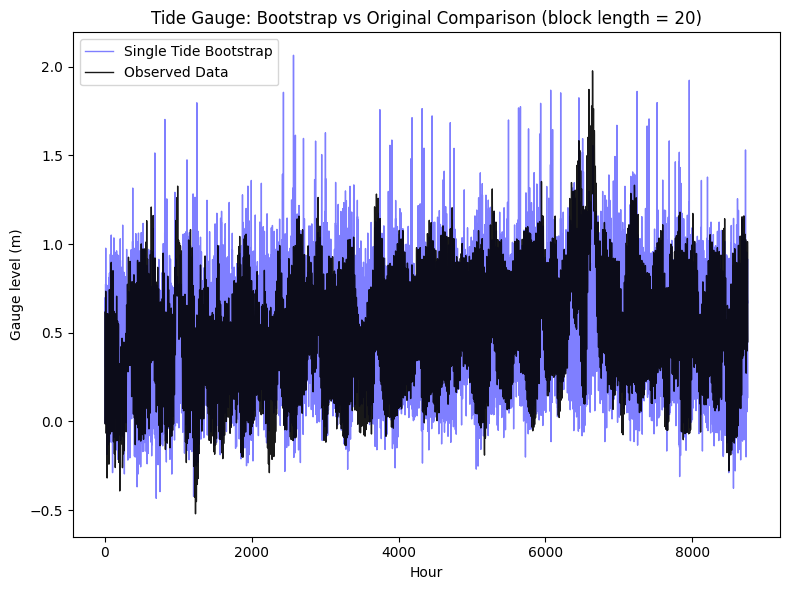

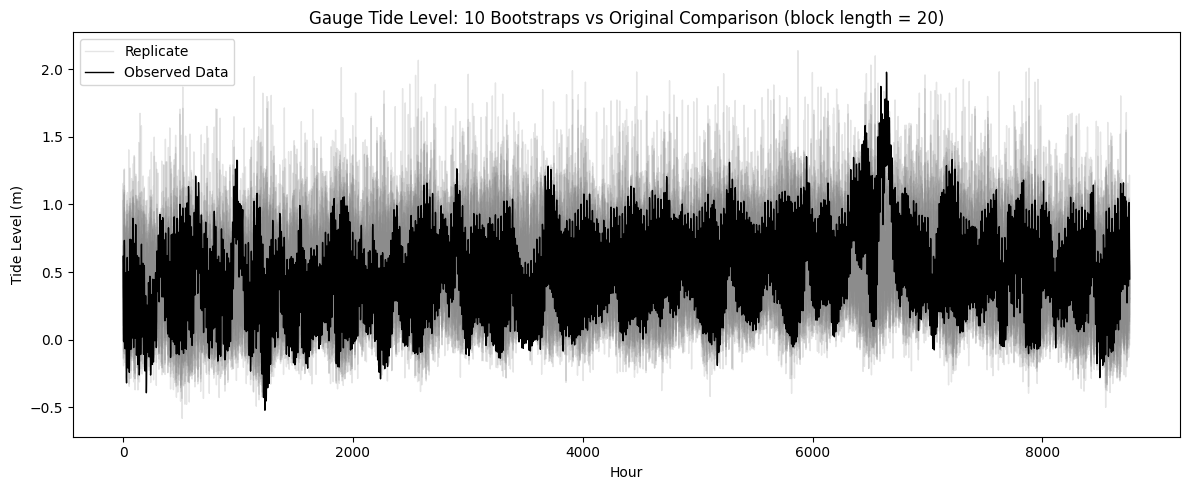

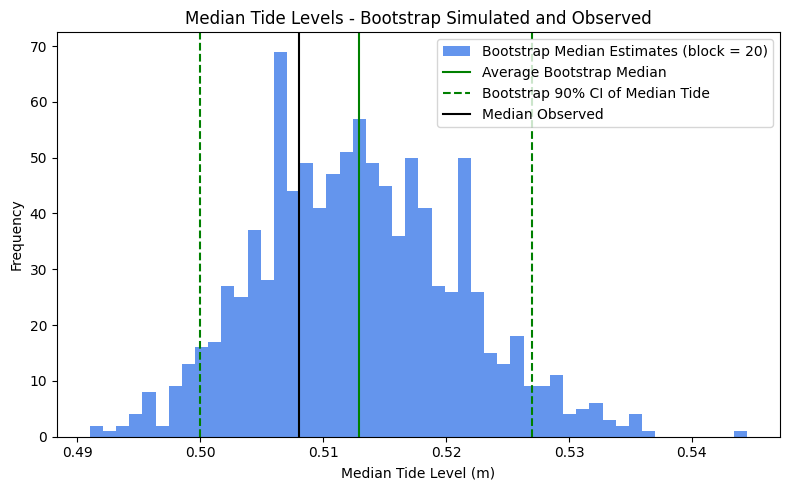

In [81]:
# create block bootstrap replicate of the weather-induced variability series (with block length 20) 
np.random.seed(44)
k = 20
n_blocks = len(dat["weather"]) - k + 1
blocks = np.zeros((k, n_blocks))
for i in range(n_blocks):
    blocks[:, i] = dat["weather"][i:(i + k)]

m = int(np.ceil(len(dat["weather"]) / k))
n_boot = 1000
weather_bootstrap20 = np.zeros((len(dat["weather"]), n_boot))
tide_bootstrap20 = np.zeros((len(dat["weather"]), n_boot))
median_tide_20 = []

# for each bootstrap sample - sample randomly from blocks, save weather variability bootstrap, and add it to
# harmonic to get actual tide bootstrap. Calculate and save median tide level from tide bootstrap for confidence intervals
for i in range(n_boot):
    block_sample_idx = np.random.choice(n_blocks, size=m, replace=True)
    resampled = np.concatenate(blocks[:, block_sample_idx], axis=0)
    weather_bootstrap20[:, i] = resampled[:len(dat["weather"])]  # Trim to original length if oversampled
    tide_bootstrap20[:, i] = dat['harmonic'] + weather_bootstrap20[:, i]
    # calculate and store median tide level:
    median_tide_20.append(np.median(tide_bootstrap20[:, i]))

# Use replicates to compute a 90% confidence interval in median tide level
median20_expected = np.mean(median_tide_20)
median20_05, median20_95 = np.quantile(median_tide_20, [0.05, 0.95])
print(f'The bootstrap (block length = 20) estimated median tide level is {round(median20_expected, 2)} meters;')
print(f'the 90% confidence interval in median tide level is {round(median20_05, 2)} m to {round(median20_95,2)} m.')

# What is the bias of the estimator? i.e., difference between average median tide from bootstraps, and the actual observed median:
median20_bias = tide_median_observed - median20_expected
print(f'The bias in this estimator (observed median minus bootstrap estiamte) is {round(median20_bias, 4)} m.')

# Plot weather bootstrap
plt.figure(figsize=(8, 6))
plt.plot(weather_bootstrap20[:, 0], color="blue", linewidth=1, label="Single Bootstrap Replicate", alpha=0.5)
plt.plot(dat["weather"], color="black", linewidth=1, label="Detrended Data", alpha=0.9)
plt.xlabel("Hour")
plt.ylabel("Gauge Weather Variability (m)")
plt.title("Gauge Weather Variability Bootstrap vs Original Comparison (block length = 20)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 10 bootstrap replicates
plt.figure(figsize=(12, 5))
plt.xlabel("Hour")
plt.ylabel("Gauge Weather Variability (m)")
plt.title("Gauge Weather Variability 10 Bootstraps vs Original Comparison (block length = 20)")
for i in range(10):
    label = "Replicate" if i == 0 else None  # Only label the first replicate
    plt.plot(weather_bootstrap20[:, i], color="gray", alpha=0.2, linewidth=1, label=label)
# Plot original data
plt.plot(dat["weather"], color="black", linewidth=1, label="Data")
plt.legend()
plt.tight_layout()
plt.show()

# Plot tide bootstrap
plt.figure(figsize=(8, 6))
plt.plot(tide_bootstrap20[:, 0], color="blue", linewidth=1, label="Single Tide Bootstrap", alpha=0.5)
plt.plot(dat["gauge"], color="black", linewidth=1, label="Observed Data", alpha=0.9)
plt.xlabel("Hour")
plt.ylabel("Gauge level (m)")
plt.title("Tide Gauge: Bootstrap vs Original Comparison (block length = 20)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 10 bootstrap replicates
plt.figure(figsize=(12, 5))
plt.xlabel("Hour")
plt.ylabel("Tide Level (m)")
plt.title("Gauge Tide Level: 10 Bootstraps vs Original Comparison (block length = 20)")
for i in range(10):
    label = "Replicate" if i == 0 else None  # Only label the first replicate
    plt.plot(tide_bootstrap20[:, i], color="gray", alpha=0.2, linewidth=1, label=label)
# Plot original data
plt.plot(dat["gauge"], color="black", linewidth=1, label="Observed Data")
plt.legend()
plt.tight_layout()
plt.show()


# Plot the simulated time series median tide levels:
plt.figure(figsize=(8, 5))
plt.hist(median_tide_20, bins = 50, color = 'cornflowerblue', label = 'Bootstrap Median Estimates (block = 20)')
plt.axvline(x=median20_expected, color = 'green', label='Average Bootstrap Median ')
plt.axvline(x=median20_05, color = 'green', linestyle='--', label='Bootstrap 90% CI of Median Tide')
plt.axvline(x=median20_95, color = 'green', linestyle='--')
#plt.axvline(x=np.median(dat['harmonic']), color = 'red', label='Median Harmonic ')
plt.axvline(x=tide_median_observed, color = 'black', label='Median Observed')
plt.xlabel("Median Tide Level (m)")
plt.ylabel("Frequency")
plt.legend()
plt.title(fr"Median Tide Levels - Bootstrap Simulated and Observed")
plt.tight_layout()
plt.show()

The bootstrap (block length = 20) estimated median tide level is 0.51 meters;
the 90% confidence interval in median tide level is 0.49 m to 0.53 m.
The bias in this estimator (observed median minus bootstrap estiamte) is -0.005 m.


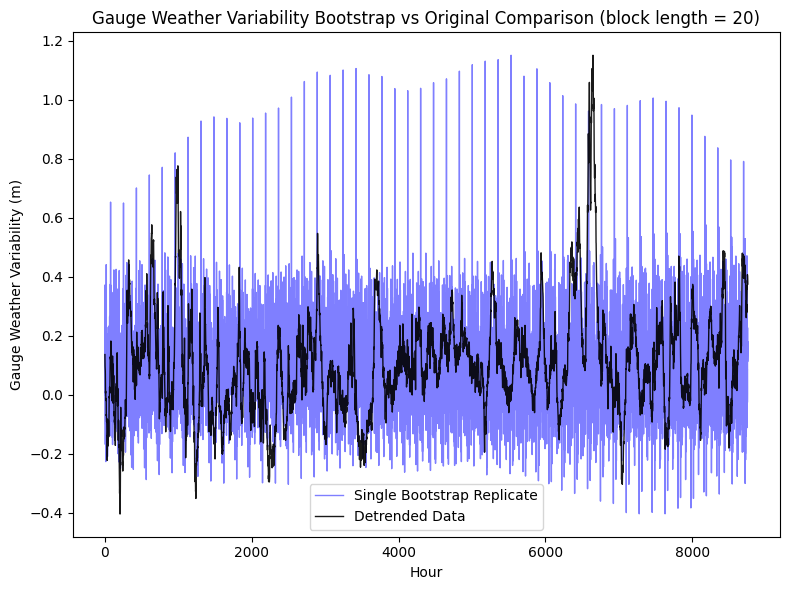

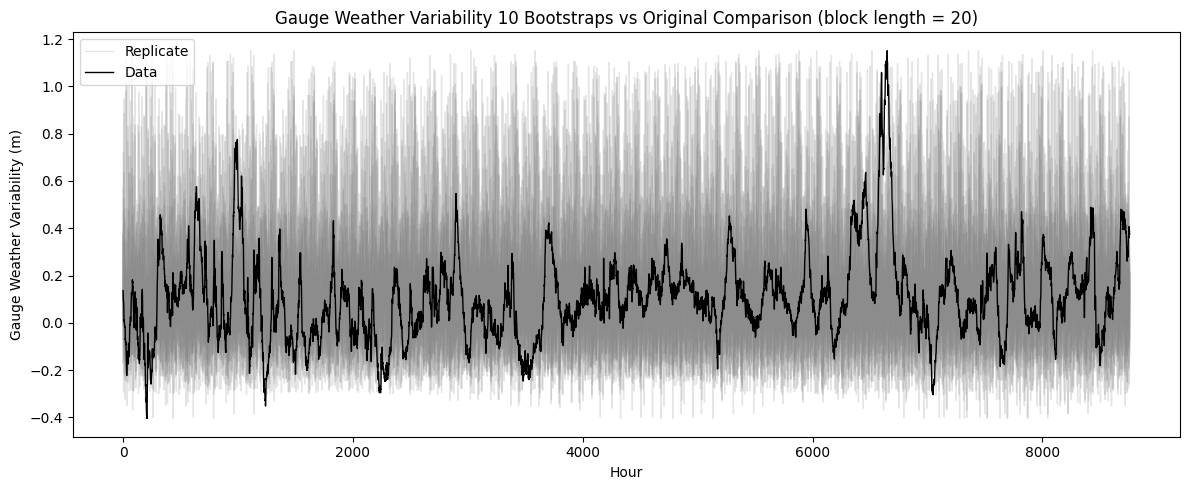

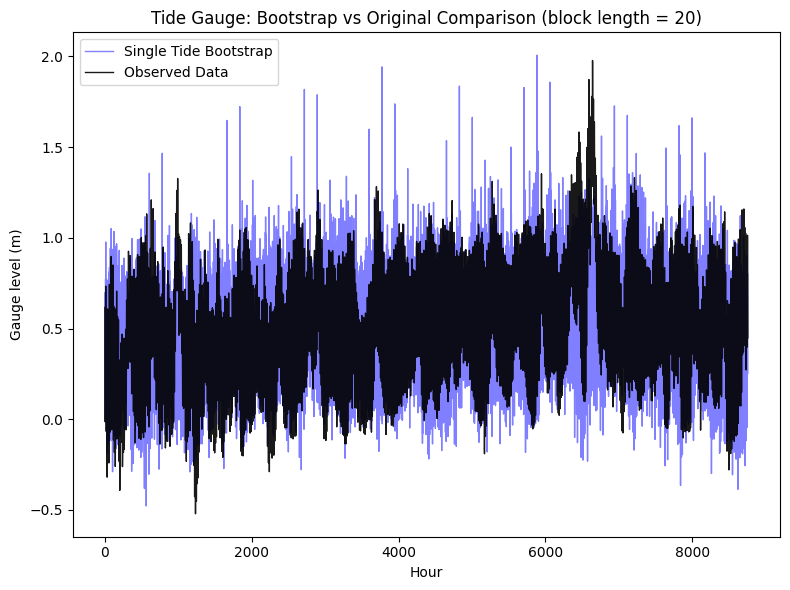

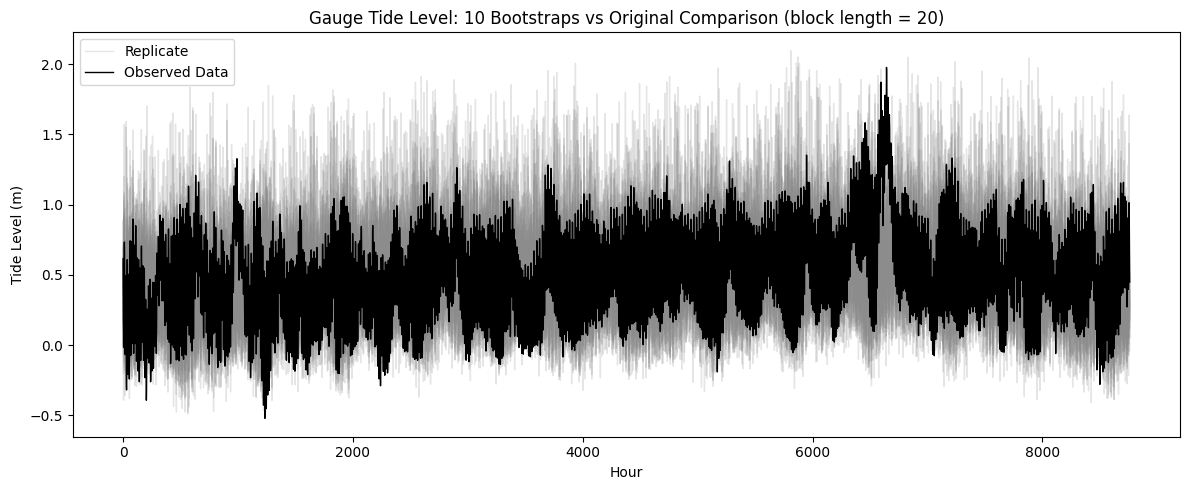

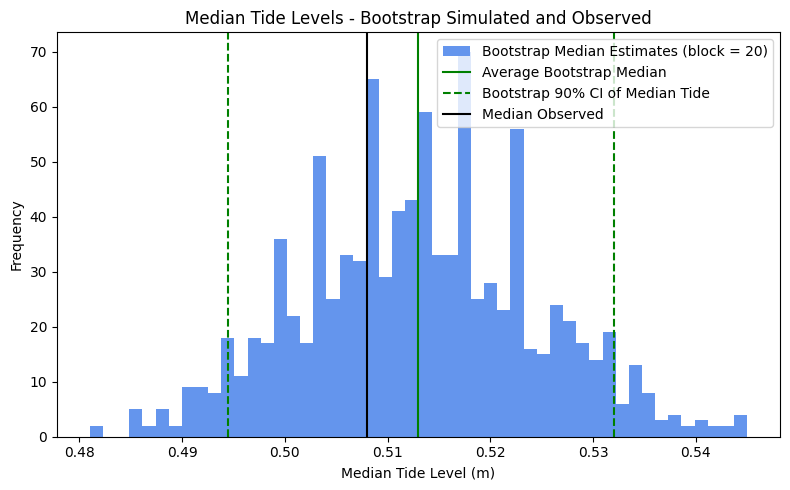

In [82]:
# create block bootstrap replicate of the weather-induced variability series (with block length 20) 
np.random.seed(44)
k = 50
n_blocks = len(dat["weather"]) - k + 1
blocks = np.zeros((k, n_blocks))
for i in range(n_blocks):
    blocks[:, i] = dat["weather"][i:(i + k)]

m = int(np.ceil(len(dat["weather"]) / k))
n_boot = 1000
weather_bootstrap20 = np.zeros((len(dat["weather"]), n_boot))
tide_bootstrap20 = np.zeros((len(dat["weather"]), n_boot))
median_tide_20 = []

# for each bootstrap sample - sample randomly from blocks, save weather variability bootstrap, and add it to
# harmonic to get actual tide bootstrap. Calculate and save median tide level from tide bootstrap for confidence intervals
for i in range(n_boot):
    block_sample_idx = np.random.choice(n_blocks, size=m, replace=True)
    resampled = np.concatenate(blocks[:, block_sample_idx], axis=0)
    weather_bootstrap20[:, i] = resampled[:len(dat["weather"])]  # Trim to original length if oversampled
    tide_bootstrap20[:, i] = dat['harmonic'] + weather_bootstrap20[:, i]
    # calculate and store median tide level:
    median_tide_20.append(np.median(tide_bootstrap20[:, i]))

# Use replicates to compute a 90% confidence interval in median tide level
median20_expected = np.mean(median_tide_20)
median20_05, median20_95 = np.quantile(median_tide_20, [0.05, 0.95])
print(f'The bootstrap (block length = 20) estimated median tide level is {round(median20_expected, 2)} meters;')
print(f'the 90% confidence interval in median tide level is {round(median20_05, 2)} m to {round(median20_95,2)} m.')

# What is the bias of the estimator? i.e., difference between average median tide from bootstraps, and the actual observed median:
median20_bias = tide_median_observed - median20_expected
print(f'The bias in this estimator (observed median minus bootstrap estiamte) is {round(median20_bias, 4)} m.')

# Plot weather bootstrap
plt.figure(figsize=(8, 6))
plt.plot(weather_bootstrap20[:, 0], color="blue", linewidth=1, label="Single Bootstrap Replicate", alpha=0.5)
plt.plot(dat["weather"], color="black", linewidth=1, label="Detrended Data", alpha=0.9)
plt.xlabel("Hour")
plt.ylabel("Gauge Weather Variability (m)")
plt.title("Gauge Weather Variability Bootstrap vs Original Comparison (block length = 20)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 10 bootstrap replicates
plt.figure(figsize=(12, 5))
plt.xlabel("Hour")
plt.ylabel("Gauge Weather Variability (m)")
plt.title("Gauge Weather Variability 10 Bootstraps vs Original Comparison (block length = 20)")
for i in range(10):
    label = "Replicate" if i == 0 else None  # Only label the first replicate
    plt.plot(weather_bootstrap20[:, i], color="gray", alpha=0.2, linewidth=1, label=label)
# Plot original data
plt.plot(dat["weather"], color="black", linewidth=1, label="Data")
plt.legend()
plt.tight_layout()
plt.show()

# Plot tide bootstrap
plt.figure(figsize=(8, 6))
plt.plot(tide_bootstrap20[:, 0], color="blue", linewidth=1, label="Single Tide Bootstrap", alpha=0.5)
plt.plot(dat["gauge"], color="black", linewidth=1, label="Observed Data", alpha=0.9)
plt.xlabel("Hour")
plt.ylabel("Gauge level (m)")
plt.title("Tide Gauge: Bootstrap vs Original Comparison (block length = 20)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot 10 bootstrap replicates
plt.figure(figsize=(12, 5))
plt.xlabel("Hour")
plt.ylabel("Tide Level (m)")
plt.title("Gauge Tide Level: 10 Bootstraps vs Original Comparison (block length = 20)")
for i in range(10):
    label = "Replicate" if i == 0 else None  # Only label the first replicate
    plt.plot(tide_bootstrap20[:, i], color="gray", alpha=0.2, linewidth=1, label=label)
# Plot original data
plt.plot(dat["gauge"], color="black", linewidth=1, label="Observed Data")
plt.legend()
plt.tight_layout()
plt.show()


# Plot the simulated time series median tide levels:
plt.figure(figsize=(8, 5))
plt.hist(median_tide_20, bins = 50, color = 'cornflowerblue', label = 'Bootstrap Median Estimates (block = 20)')
plt.axvline(x=median20_expected, color = 'green', label='Average Bootstrap Median ')
plt.axvline(x=median20_05, color = 'green', linestyle='--', label='Bootstrap 90% CI of Median Tide')
plt.axvline(x=median20_95, color = 'green', linestyle='--')
#plt.axvline(x=np.median(dat['harmonic']), color = 'red', label='Median Harmonic ')
plt.axvline(x=tide_median_observed, color = 'black', label='Median Observed')
plt.xlabel("Median Tide Level (m)")
plt.ylabel("Frequency")
plt.legend()
plt.title(fr"Median Tide Levels - Bootstrap Simulated and Observed")
plt.tight_layout()
plt.show()

In this problem, I constructed 1,000 bootstrap replicates of tide levels using a moving block bootstrap (with block length 20, and block length 50) of weather-induced tidal variability, which was then added to the harmonic prediction to get a bootstrap sample of tide levels. After obtaining these 1,000 bootstrap replicates, I computed the bootstrap estimate of the median tide level, and the 90% confidence interval associated with this estimate. The estimated median tide level was 0.51 m, and the bias in this estimate was -0.004 m for both the bootstrap replicates (blcok length 20 and 50). However, the 90% confidence interval is different for the two different block length bootstraps: for the bootstrap with block length 20, the 90% confidence interval was 0.5 m to 0.53 m; for the bootstrap with block length 50, the 90% confidence interval was 0.49 m to 0.53 m. I think that using the longer block length produces a wider 90% confidence interval because XXXX. The choice of block length did not impact the bias because XXXXXX.


by adding a moving block
    bootstrap replicate from the weather-induced variability series
    (with block length 20) to the harmonic prediction. Use these
    replicates to compute a 90% confidence interval. What is the bias of
    the estimator?
-   Repeat the analysis with block length 50. How does this affect the
    confidence intervals and estimate of bias?
-   Why do you think using different block lengths produced the results
    that they did?

## References

OpenAI. (2025). ChatGPT (April 9 version) [Large language model]. https://chatgpt.com/
